# XDF quick analysis

Analyze `260602_sub1_hjlee.xdf` directly: stream/marker summaries, class-wise cue summaries, and 2-second EEG waveforms from imagination cue markers `101`-`105`.

In [86]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyxdf
from IPython.display import display

# 분석할 XDF 파일. 다른 날짜를 볼 때는 이 줄만 바꾼 뒤 위에서부터 다시 실행한다.
XDF_PATH = Path('/home/jihoon/workspace/Demo_binary/260602_sub1_hjlee.xdf')
# 예: XDF_PATH = Path('/home/jihoon/workspace/Demo/260520_sub1_hjlee.xdf')

IMAGERY_CUES = ['101', '102', '103', '104', '105']
TRIAL_MARKERS = ['1', '2', '3', '4', '5']

def scalar(value, default=''):
    while isinstance(value, (list, tuple)) and value:
        value = value[0]
    return default if value in (None, []) else value

def channel_labels(stream):
    desc = scalar(stream.get('info', {}).get('desc'), {}) or {}
    channels_group = scalar(desc.get('channels'), {}) if isinstance(desc, dict) else {}
    channels = channels_group.get('channel', []) if isinstance(channels_group, dict) else []
    labels = [str(scalar(ch.get('label'), f'ch{i + 1}')) for i, ch in enumerate(channels)]
    return labels

XDF_PATH = XDF_PATH.resolve()
print(XDF_PATH)

/home/jihoon/workspace/Demo_binary/260602_sub1_hjlee.xdf


## Marker load

In [87]:
marker_loaded_path = XDF_PATH
marker_streams, _ = pyxdf.load_xdf(str(marker_loaded_path), select_streams=[{'type': 'Markers'}])
marker_stream = marker_streams[0]

marker_values_raw = np.asarray(marker_stream['time_series'], dtype=object)
marker_timestamps = np.asarray(marker_stream['time_stamps'], dtype=float)

if marker_values_raw.ndim == 1:
    marker_values = np.asarray([str(value) for value in marker_values_raw], dtype=str)
else:
    marker_values = np.asarray(['|'.join(map(str, np.ravel(row))) for row in marker_values_raw], dtype=str)

marker_df = pd.DataFrame({
    'marker_idx': np.arange(len(marker_values)),
    'marker': marker_values,
    'timestamp': marker_timestamps,
})
marker_df['time_from_start_s'] = marker_df['timestamp'] - marker_df['timestamp'].iloc[0]
marker_df.head()

,marker_idx,marker,timestamp,time_from_start_s
0,0,session/1,2.334949e+06,0.000000
1,1,0,2.334949e+06,0.020359
2,2,start,2.334951e+06,2.071608
3,3,0,2.334951e+06,2.074522
4,4,104,2.334952e+06,3.055124


## Overall summary

In [88]:
marker_info = marker_stream.get('info', {})

overall_summary = pd.DataFrame([{
    'xdf_file': XDF_PATH.name,
    'marker_stream_name': scalar(marker_info.get('name')),
    'marker_stream_type': scalar(marker_info.get('type')),
    'total_markers': len(marker_df),
    'unique_markers': marker_df['marker'].nunique(),
    'duration_s': marker_df['time_from_start_s'].iloc[-1],
    'imagery_cue_count_101_105': marker_df['marker'].isin(IMAGERY_CUES).sum(),
    'trial_marker_count_1_5': marker_df['marker'].isin(TRIAL_MARKERS).sum(),
}])

overall_summary

,xdf_file,marker_stream_name,marker_stream_type,total_markers,unique_markers,duration_s,imagery_cue_count_101_105,trial_marker_count_1_5
0,260602_sub1_hjlee.xdf,trigger_stream,Markers,1078,15,2373.838392,500,500


In [89]:
marker_count_df = (
    marker_df['marker']
    .value_counts()
    .rename_axis('marker')
    .reset_index(name='count')
)
marker_count_df

,marker,count
0,104,100
1,4,100
2,105,100
3,5,100
4,103,100
5,3,100
6,101,100
7,1,100
8,102,100
9,2,100


## Class-wise summary

In [90]:
class_rows = []

for class_id in range(1, 6):
    cue_marker = str(100 + class_id)
    trial_marker = str(class_id)
    cue_times = marker_df.loc[marker_df['marker'] == cue_marker, 'timestamp'].to_numpy()
    trial_times = marker_df.loc[marker_df['marker'] == trial_marker, 'timestamp'].to_numpy()
    cue_intervals = np.diff(cue_times)

    class_rows.append({
        'class_id': class_id,
        'imagery_cue_marker': cue_marker,
        'imagery_cue_count': len(cue_times),
        'trial_marker': trial_marker,
        'trial_marker_count': len(trial_times),
        'first_cue_s': cue_times[0] - marker_timestamps[0] if len(cue_times) else np.nan,
        'last_cue_s': cue_times[-1] - marker_timestamps[0] if len(cue_times) else np.nan,
        'mean_cue_interval_s': cue_intervals.mean() if len(cue_intervals) else np.nan,
        'min_cue_interval_s': cue_intervals.min() if len(cue_intervals) else np.nan,
        'max_cue_interval_s': cue_intervals.max() if len(cue_intervals) else np.nan,
    })

class_summary = pd.DataFrame(class_rows)
class_summary

,class_id,imagery_cue_marker,imagery_cue_count,trial_marker,trial_marker_count,first_cue_s,last_cue_s,mean_cue_interval_s,min_cue_interval_s,max_cue_interval_s
0,1,101,100,1,100,15.961612,2359.266102,23.669742,4.247099,112.084639
1,2,102,100,2,100,49.985776,2367.771725,23.411979,4.243630,182.111297
2,3,103,100,3,100,11.717452,2346.521089,23.583875,4.239282,117.967578
3,4,104,100,4,100,3.055124,2295.483758,23.155845,4.246319,96.093827
4,5,105,100,5,100,7.453448,2338.009855,23.540974,4.244765,106.570555


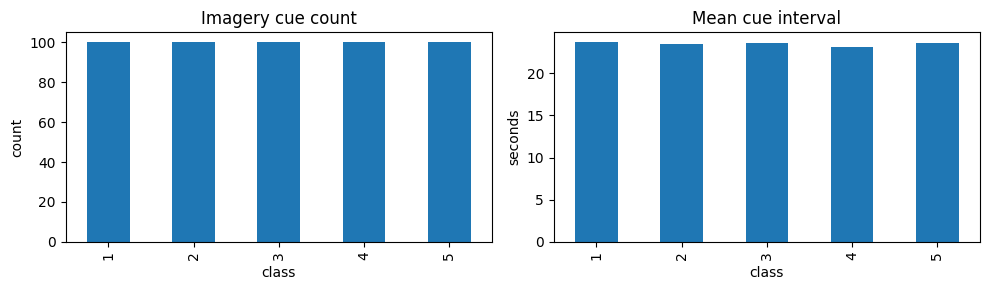

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

class_summary.plot(x='class_id', y='imagery_cue_count', kind='bar', ax=axes[0], legend=False)
axes[0].set_title('Imagery cue count')
axes[0].set_xlabel('class')
axes[0].set_ylabel('count')

class_summary.plot(x='class_id', y='mean_cue_interval_s', kind='bar', ax=axes[1], legend=False)
axes[1].set_title('Mean cue interval')
axes[1].set_xlabel('class')
axes[1].set_ylabel('seconds')

plt.tight_layout()

## Plot 2 seconds from one imagery cue

`CUE_MARKER`, `TRIAL_NO`, `MODE`만 바꾸면 상상 큐부터 2초 동안 EEG 또는 EMG 평균 파형을 그립니다.

file: 260602_sub1_hjlee.xdf
EEG 평균 채널 수: 64, sample 수: 4000


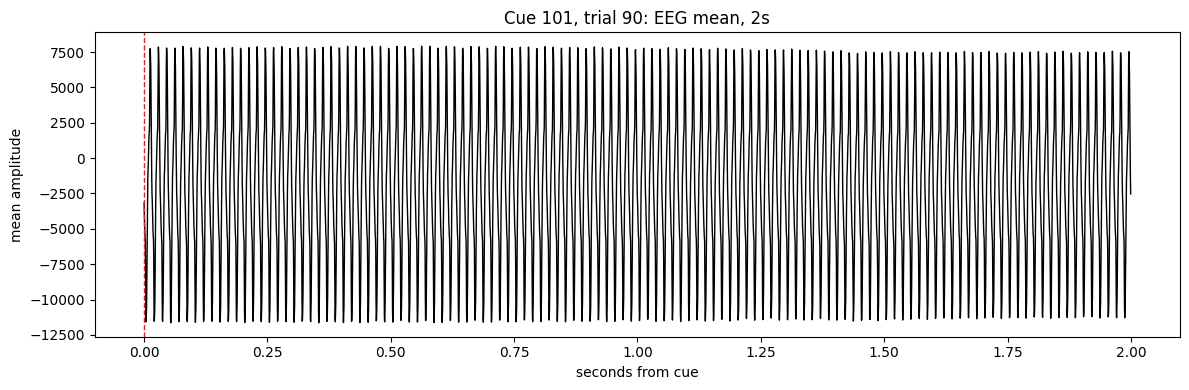

In [94]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pyxdf

# XDF_PATH = Path('/home/jihoon/workspace/Demo/260520_sub1_hjlee.xdf')
XDF_PATH = Path('/home/jihoon/workspace/Demo_binary/260602_sub1_hjlee.xdf')
CUE_MARKER = '101'
TRIAL_NO = 90
MODE = 'EEG'  # 'EEG' 또는 'EMG'

# 이 셀은 혼동을 막기 위해 marker와 EEG를 같은 XDF에서 직접 읽는다.
marker_stream = pyxdf.load_xdf(str(XDF_PATH), select_streams=[{'type': 'Markers'}])[0][0]
eeg_stream = pyxdf.load_xdf(str(XDF_PATH), select_streams=[{'type': 'EEG'}])[0][0]

# marker 값과 시간을 꺼낸다.
marker_raw = np.asarray(marker_stream['time_series'], dtype=object)
marker_values = np.asarray(['|'.join(map(str, np.ravel(row))) for row in marker_raw], dtype=str)
marker_times = np.asarray(marker_stream['time_stamps'], dtype=float)

# 선택한 상상 큐의 n번째 trial 시작 시간을 찾는다.
cue_times = marker_times[marker_values == CUE_MARKER]
if not (1 <= TRIAL_NO <= len(cue_times)):
    raise ValueError(f'{CUE_MARKER} trial은 1~{len(cue_times)}만 입력하세요.')
cue_time = cue_times[TRIAL_NO - 1]

# EEG/EMG 데이터와 채널 이름을 꺼낸다.
data = np.asarray(eeg_stream['time_series'], dtype=float)
times = np.asarray(eeg_stream['time_stamps'], dtype=float)
if 'channel_labels' in globals():
    labels = channel_labels(eeg_stream)
else:
    desc = eeg_stream['info'].get('desc', [{}])[0] or {}
    channels = ((desc.get('channels', [{}])[0] or {}).get('channel', []))
    labels = [str((ch.get('label') or [f'ch{i + 1}'])[0]) for i, ch in enumerate(channels)]
labels = labels or [f'ch{i + 1}' for i in range(data.shape[1])]

# 상상 큐부터 2초 구간만 자른다.
start = np.searchsorted(times, cue_time)
stop = np.searchsorted(times, cue_time + 2.0)
if stop <= start:
    raise RuntimeError('2초 구간 sample이 없습니다. XDF_PATH와 cue marker를 확인하세요.')

# MODE에 따라 EEG끼리 평균, EMG끼리 평균을 낸다.
emg_idx = [i for i, ch in enumerate(labels) if str(ch).upper().startswith('EMG')]
eeg_idx = [i for i in range(data.shape[1]) if i not in emg_idx]
idx = eeg_idx if MODE.upper() == 'EEG' else emg_idx
if not idx:
    raise ValueError(f'{MODE} 채널을 찾지 못했습니다.')

time_s = times[start:stop] - cue_time
mean_wave = data[start:stop, idx].mean(axis=1)

print(f'file: {XDF_PATH.name}')
print(f'{MODE.upper()} 평균 채널 수: {len(idx)}, sample 수: {len(mean_wave)}')

plt.figure(figsize=(12, 4))
plt.plot(time_s, mean_wave, color='black', lw=1)
plt.axvline(0, color='tab:red', ls='--', lw=1)
plt.title(f'Cue {CUE_MARKER}, trial {TRIAL_NO}: {MODE.upper()} mean, 2s')
plt.xlabel('seconds from cue')
plt.ylabel('mean amplitude')
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import pyxdf

def scalar(value, default=''):
    while isinstance(value, (list, tuple)) and value:
        value = value[0]
    return default if value in (None, []) else value

# 현재 노트북에서 보고 싶은 XDF 하나만 지정한다.
# 위 셀의 XDF_PATH를 그대로 쓰고 싶으면 이 줄은 지워도 된다.
XDF_PATH = Path('/home/jihoon/workspace/Demo_binary/260602_sub1_hjlee.xdf')

# XDF 안에는 EEG, Markers 같은 여러 stream이 list로 들어있다.
streams, header = pyxdf.load_xdf(str(XDF_PATH))

print(f'file: {XDF_PATH.name}')
print(f'header keys: {list(header.keys())}')
print(f'stream 개수: {len(streams)}')

summary_rows = []
for i, stream in enumerate(streams):
    info = stream['info']
    data = np.asarray(stream['time_series'], dtype=object)
    times = np.asarray(stream['time_stamps'])

    # info 값은 ['EEG']처럼 list 안에 들어있는 경우가 많아서 scalar()로 첫 값만 꺼낸다.
    name = scalar(info.get('name'))
    stream_type = scalar(info.get('type'))
    channel_count = scalar(info.get('channel_count'))
    nominal_srate = scalar(info.get('nominal_srate'))

    summary_rows.append({
        'stream_idx': i,
        'name': name,
        'type': stream_type,
        'channel_count': channel_count,
        'nominal_srate': nominal_srate,
        'time_series_shape': data.shape,
        'time_stamps_shape': times.shape,
        'first_timestamp': times[0] if len(times) else np.nan,
        'last_timestamp': times[-1] if len(times) else np.nan,
    })

stream_summary = pd.DataFrame(summary_rows)
display(stream_summary)

# 각 stream의 실제 데이터가 어떻게 생겼는지 앞 3개만 찍어본다.
for i, stream in enumerate(streams):
    info = stream['info']
    name = scalar(info.get('name'))
    data = np.asarray(stream['time_series'], dtype=object)
    times = np.asarray(stream['time_stamps'])

    print('\n' + '=' * 60)
    print(f'stream[{i}] name={name!r}')
    print(f'info keys: {list(info.keys())}')
    print(f'time_stamps[:3]: {times[:3]}')
    print(f'time_series[:3]:')
    print(data[:3])

# trigger_stream은 marker 값이 들어있는 stream이다. 값별 빈도를 센다.
marker_stream = next(stream for stream in streams if scalar(stream['info'].get('name')) == 'trigger_stream')
markers = np.asarray(marker_stream['time_series'], dtype=object).flatten()
marker_counts = Counter(map(str, markers.tolist()))

marker_count_df = pd.DataFrame(
    sorted(marker_counts.items()),
    columns=['marker', 'count'],
)

print(f'\nTotal triggers: {len(markers)}')
display(marker_count_df)


## Check the truncated/corrupted-read point

선배님 출력처럼 marker가 `895`개까지만 읽혔을 때, 원래 기대한 전체 marker와 무엇이 다른지 확인합니다.

In [ ]:
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import pyxdf
from IPython.display import display

# 선배님 출력의 Total triggers 값. 여기까지만 읽히면 뒤 marker들이 누락된 상태다.
SENIOR_READ_N = 895
XDF_PATH = Path("/home/jihoon/workspace/Demo_binary/260602_sub1_hjlee.xdf")

# marker stream만 읽는다. EEG 전체 파형은 필요 없어서 빠르다.
marker_stream = pyxdf.load_xdf(str(XDF_PATH), select_streams=[{"type": "Markers"}])[0][0]
raw = np.asarray(marker_stream["time_series"], dtype=object)
markers = np.asarray(["|".join(map(str, np.ravel(row))) for row in raw], dtype=str)
times = np.asarray(marker_stream["time_stamps"], dtype=float)

full_counts = Counter(markers)
senior_counts = Counter(markers[:SENIOR_READ_N])
missing_counts = Counter(markers[SENIOR_READ_N:])

# 이전 정상 데이터/실험 설계상 기대: 5개 class cue와 trial marker가 각각 100개씩 있어야 한다.
expected = {str(i): 100 for i in range(1, 6)}
expected.update({str(100 + i): 100 for i in range(1, 6)})
expected.update({"end": 1})

rows = []
for marker in ["101", "102", "103", "104", "105", "1", "2", "3", "4", "5", "0", "continue", "start", "end"]:
    rows.append({
        "marker": marker,
        "expected_if_complete": expected.get(marker, "-"),
        "full_xdf_count": full_counts.get(marker, 0),
        "senior_895_count": senior_counts.get(marker, 0),
        "missing_after_895": missing_counts.get(marker, 0),
    })

display(pd.DataFrame(rows))

# 895 이후에 남아 있던 marker들이 곧 선배님 환경에서 못 읽은 부분이다.
missing_df = pd.DataFrame({
    "global_marker_idx": np.arange(SENIOR_READ_N, len(markers)),
    "marker": markers[SENIOR_READ_N:],
    "time_from_first_marker_s": times[SENIOR_READ_N:] - times[0],
})

print(f"전체 marker 수: {len(markers)}")
print(f"선배님 쪽에서 읽힌 marker 수: {SENIOR_READ_N}")
print(f"누락된 marker 수: {len(markers) - SENIOR_READ_N}")
print(f"누락 시작 marker index: {SENIOR_READ_N}")
display(missing_df.head(20))

# 누락된 구간이 각 class의 몇 번째 cue/trial부터인지 확인한다.
event_rows = []
class_markers = ["101", "102", "103", "104", "105", "1", "2", "3", "4", "5"]
seen = Counter()
for idx, marker in enumerate(markers):
    if marker not in class_markers:
        continue
    seen[marker] += 1
    if idx >= SENIOR_READ_N:
        event_rows.append({
            "global_marker_idx": idx,
            "marker": marker,
            "class_trial_no": seen[marker],
            "time_from_first_marker_s": times[idx] - times[0],
        })

print("895 이후에 남아 있던 class cue/trial marker들:")
display(pd.DataFrame(event_rows).head(30))
